In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import os
import scanpy as sc 
import torch
import numpy as np

from spatial_gnn.api.perturbation_api import (
    train_perturbation_model,
    create_perturbation_input_matrix,
    predict_perturbation_effects
)
from spatial_gnn.utils.plot_utils import (
    plot_loss_curves,
    plot_celltype_performance,
    plot_celltypes_in_section,
    plot_propagation_results_for_gene_set
)

/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from 

# 1. Load Data

In [4]:
adata = sc.read(
    "/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202.h5ad",
    backup_url="https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [5]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

## Data splits

In [7]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_celltype = ["Fibroblast"]
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    #is_holdout_ct = adata.obs["coarse_type"].isin(holdout_celltype)
    is_holdout_ct = adata.obs['coarse_type']!="Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [8]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [9]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [10]:
adata.obs['data_split'] = 'train'
adata.obs.iloc[val_idx, adata.obs.columns.get_loc('data_split')] = 'valid'
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('data_split')] = 'ood'

# Train

In [12]:
! mkdir -p ./data
! if [ ! -f /data2/a330d/aging_coronal.h5ad ]; then \
      echo "Downloading aging_coronal.h5ad..."; \
      wget https://zenodo.org/records/13883177/files/aging_coronal.h5ad -O /data2/a330d/aging_coronal.h5ad; \
    else \
      echo "File already exists: /data2/a330d/aging_coronal.h5ad — skipping download."; \
  fi

--2026-02-24 17:35:14--  https://zenodo.org/records/13883177/files/aging_coronal.h5ad
Resolving www-int.dkfz-heidelberg.de (www-int.dkfz-heidelberg.de)... 193.174.53.28
Connecting to www-int.dkfz-heidelberg.de (www-int.dkfz-heidelberg.de)|193.174.53.28|:80... connected.
Proxy request sent, awaiting response... 200 OK
Length: 4227749424 (3.9G) [application/octet-stream]
Saving to: ‘/data2/a330d/aging_coronal.h5ad’

/data2/a330d/aging_ 100%[===================>]   3.94G   111MB/s    in 36s     

2026-02-24 17:35:50 (111 MB/s) - ‘/data2/a330d/aging_coronal.h5ad’ saved [4227749424/4227749424]



In [22]:
ada = sc.read_h5ad("/data2/a330d/aging_coronal.h5ad")

In [ ]:
ada.obs.columns

Index(['volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y',
       'transcript_count', 'num_detected_genes', 'barcodeCount', 'mouse_id',
       'slide_id', 'cohort', 'age', 'batch', 'celltype', 'region',
       'subregion'],
      dtype='object')

In [18]:
ada.obs.mouse_id.value_counts()

mouse_id
75     86801
80     86061
93     85137
86     85027
97     82641
14     80194
57     79824
61     78862
101    73775
53     73309
70     72453
7      68707
11     68661
33     66538
42     66416
19     65870
1      62296
30     61534
38     59404
46     49634
Name: count, dtype: int64

In [4]:
adata_path = "/data2/a330d/aging_coronal.h5ad"
train_ids = ["14"]
test_ids = ["57"]
exp_name = "api_demo"

In [5]:
training_args = {
    "dataset": "aging_coronal",
    "file_path": adata_path,
    "train_ids": train_ids, 
    "test_ids": test_ids,
    "exp_name": exp_name,
    "k_hop": 2,
    "augment_hop": 2,
    "center_celltypes": "all",
    "node_feature": "expression",
    "inject_feature": "none",
    "learning_rate": 0.0001,
    "loss": "weightedl1",
    "epochs": 3, #30,
    "normalize_total": True,
    "num_cells_per_ct_id": 100,
    "predict_celltype": False,
    "pool": "center",
    "do_eval": True,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

In [6]:
test_loader, gene_names, (model, model_config, trained_model_path) = train_perturbation_model(
    **training_args,
)

Training new perturbation model from scratch...
Model will be saved to: ./output/api_demo/aging_coronal_expression_2hop_2augment_expression_none/weightedl1_1en04
Training on device: cuda
Creating new dataset at: ./data/gnn_datasets/aging_coronal_expression_100per_2hop_2C0aug_200delaunay_expressionFeat_all_NoneInject_subset_57/test

Processing file 1/1: aging_coronal.h5ad
Normalizing data


/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Processing 1 samples
Using sequential processing for 1 samples


  0%|          | 0/1 [00:00<?, ?it/s]

Sample 1: 57 (PID: 3221221)


...

100%|██████████| 51/51 [00:04<00:00, 11.95it/s]
/data/a330d/projects/spatial-prop/src/spatial_gnn/utils/dataset_utils.py:29: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  dataloader = DataLoader(
100%|██████████| 51/51 [00:04<00:00, 12.19it/s]

Train samples: 24879
Test samples: 24997


Expression model initialized on cuda
Starting GNN training for 3 epochs...
 Epoch: 001, Train WL1: 9.5205, Test WL1: 9.5636, Test Spearman: 0.1243
 Epoch: 002, Train WL1: 8.6376, Test WL1: 8.7208, Test Spearman: 0.3268
 Epoch: 003, Train WL1: 8.0666, Test WL1: 8.1698, Test Spearman: 0.4637
GNN training completed. Model saved to output/api_demo/aging_coronal_expression_2hop_2augment_expression_none/weightedl1_1en04/model.pth
Configuration saved to output/api_demo/aging_coronal_expression_2hop_2augment_expression_none/weightedl1_1en04/config.json
GNN training logs saved
Measuring model predictive performance bulk and by cell type...


100%|██████████| 49/49 [00:01<00:00, 37.92it/s]


Computing micro and macro averages...
Finished cell type analysis.
Training completed. Model saved to: output/api_demo/aging_coronal_expression_2hop_2augment_expression_none/weightedl1_1en04/model.pth


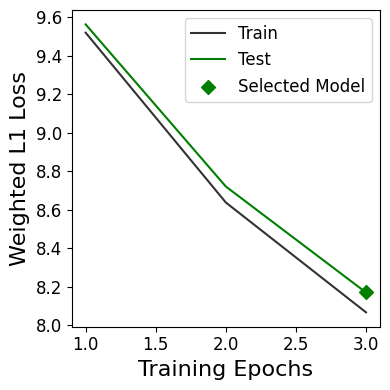

In [7]:
model_dir = os.path.dirname(trained_model_path)
plot_loss_curves(model_dir)

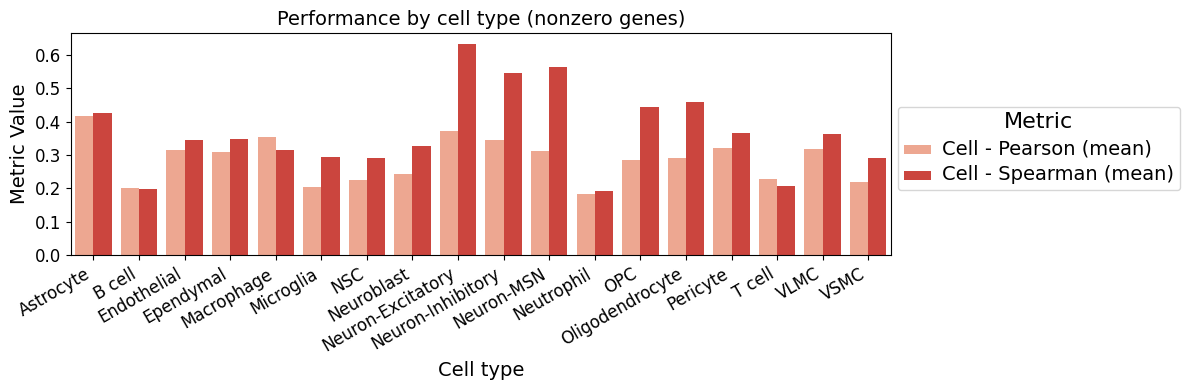

In [8]:
plot_celltype_performance(model_dir)


# Eval

In [10]:
inflammatory_genes = ["Ifng", "Il6", "Tnf", "Il1a", "Il1b", "Jun", "Apoe", "B2m", "C1qa", "Cd69", "Cd9", "Lyz2"]
perturbation_dict = {
    "T cell": {gene: 10.0 for gene in inflammatory_genes},
    "Microglia": {gene: 10.0 for gene in inflammatory_genes},
}
save_path = "/data2/a330d/perturbed_adata/aging_coronal_perturbed.h5ad"

In [11]:
adata = sc.read_h5ad(adata_path)
save_path = create_perturbation_input_matrix(adata, perturbation_dict, save_path=save_path)

Applying perturbations to 1042 cells of type 'T cell'
  - Gene 'Ifng': multiplier = 10.0
  - Gene 'Il6': multiplier = 10.0
  - Gene 'Tnf': multiplier = 10.0
  - Gene 'Il1a': multiplier = 10.0
  - Gene 'Il1b': multiplier = 10.0
  - Gene 'Jun': multiplier = 10.0
  - Gene 'Apoe': multiplier = 10.0
  - Gene 'B2m': multiplier = 10.0
  - Gene 'C1qa': multiplier = 10.0
  - Gene 'Cd69': multiplier = 10.0
  - Gene 'Cd9': multiplier = 10.0
  - Gene 'Lyz2': multiplier = 10.0
Applying perturbations to 55514 cells of type 'Microglia'
  - Gene 'Ifng': multiplier = 10.0
  - Gene 'Il6': multiplier = 10.0
  - Gene 'Tnf': multiplier = 10.0
  - Gene 'Il1a': multiplier = 10.0
  - Gene 'Il1b': multiplier = 10.0
  - Gene 'Jun': multiplier = 10.0
  - Gene 'Apoe': multiplier = 10.0
  - Gene 'B2m': multiplier = 10.0
  - Gene 'C1qa': multiplier = 10.0
  - Gene 'Cd69': multiplier = 10.0
  - Gene 'Cd9': multiplier = 10.0
  - Gene 'Lyz2': multiplier = 10.0
Saved AnnData with perturbation input to: /data2/a330d/per

In [12]:
ad_pert = sc.read_h5ad(save_path)

In [15]:
ad_pert.obs.celltype.value_counts()

celltype
Neuron-Inhibitory    336305
Neuron-Excitatory    311370
Oligodendrocyte      222730
Astrocyte            150638
Neuron-MSN           124244
Endothelial          122381
Microglia             55514
OPC                   35452
Pericyte              28257
VLMC                  28234
VSMC                  14676
Ependymal              7592
Macrophage             6389
Neuroblast             3823
NSC                    2582
Neutrophil             1175
T cell                 1042
B cell                  740
Name: count, dtype: int64

In [23]:
ada.X

array([[ 7.,  0.,  3., ...,  0.,  0.,  2.],
       [ 1.,  0.,  0., ...,  1.,  0.,  0.],
       [ 9.,  0.,  1., ...,  0.,  0., 13.],
       ...,
       [15.,  0.,  1., ...,  1.,  0.,  0.],
       [ 5.,  0.,  1., ...,  0.,  0.,  0.],
       [25.,  0.,  1., ...,  0.,  0.,  3.]], shape=(1453144, 300))

In [21]:
ad_pert.X

array([[ 7.,  0.,  3., ...,  0.,  0.,  2.],
       [ 1.,  0.,  0., ...,  1.,  0.,  0.],
       [ 9.,  0.,  1., ...,  0.,  0., 13.],
       ...,
       [15.,  0.,  1., ...,  1.,  0.,  0.],
       [ 5.,  0.,  1., ...,  0.,  0.,  0.],
       [25.,  0.,  1., ...,  0.,  0.,  3.]], shape=(1453144, 300))

In [20]:
ad_pert.obsm['perturbed_input']

array([[ 7.36842105,  0.        ,  3.15789474, ...,  0.        ,
         0.        ,  2.10526316],
       [ 0.85227273,  0.        ,  0.        , ...,  0.85227273,
         0.        ,  0.        ],
       [ 4.56081081,  0.        ,  0.50675676, ...,  0.        ,
         0.        ,  6.58783784],
       ...,
       [13.39285714,  0.        ,  0.89285714, ...,  0.89285714,
         0.        ,  0.        ],
       [ 4.71698113,  0.        ,  0.94339623, ...,  0.        ,
         0.        ,  0.        ],
       [ 9.96015936,  0.        ,  0.39840637, ...,  0.        ,
         0.        ,  1.19521912]], shape=(1453144, 300))

In [ ]:
adata_result = predict_perturbation_effects(
    save_path, trained_model_path, exp_name, use_ids=test_ids
)